# Does physics-informed latent representation learning improve generative surrogate modeling?

Two-stage pipeline on 2D Navier-Stokes:

1. **Stage 1** -- a Transformer VQ-VAE compresses velocity-field snapshots into a discrete
   latent code, trained in a **baseline** variant (reconstruction + VQ loss only) and a
   **physics-informed** variant (adds a scale-normalised divergence-free + vorticity-transport
   residual penalty -- see `training/losses.py`).
2. **Stage 2** -- a latent Flow Matching model learns to generate new codebook embeddings,
   which the frozen Stage-1 decoder turns back into velocity fields.

This notebook assumes both Stage-1 variants and Stage 2 have already been trained
(`python run.py --stage all`) and loads their checkpoints/logs directly -- it contains no
training code itself.


In [1]:
import os
import sys
from pathlib import Path

# This codebase resolves 'data/', 'outputs/', 'configs/' relative to the repo root
# throughout (see run.py, scripts/*.py) -- match that convention here regardless of
# where the Jupyter kernel happened to start, rather than only fixing sys.path.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from data.datamodule import build_dataloaders
from evaluation.evaluate_generation import evaluate_generation
from models.flow_matching.model import LatentFlowMatcher
from models.vqvae.model import TransformerVQVAE
from physics.derivatives import curl_2d
from physics.residual import divergence_error_field, vorticity_transport_residual_field
from training.checkpointing import load_frozen_model
from utils.config import (
    CONFIG_DIR, load_config, load_flow_matching_config,
    resolve_flow_matching_arch_config, resolve_vqvae_arch_config,
)
from utils.visualization import (
    compute_and_plot_tsne, plot_distribution_comparison, plot_energy_spectra,
    plot_training_curves, plot_validation_fields, plot_vorticity_comparison,
)

plt.rcParams["figure.dpi"] = 110
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

experiment_cfg = load_config(CONFIG_DIR / "experiment.yaml")
DATA_CONFIG = "data_synthetic"     # change to 'data_pdebench' / 'data_the_well' to match your training run
OUTPUT_DIR = Path(experiment_cfg.output_dir)

## Figure 1 -- Training curves

Reconstruction loss and PDE residual loss for both variants, read directly from the
per-epoch CSV logs (`outputs/metrics/*.csv`) written during training.


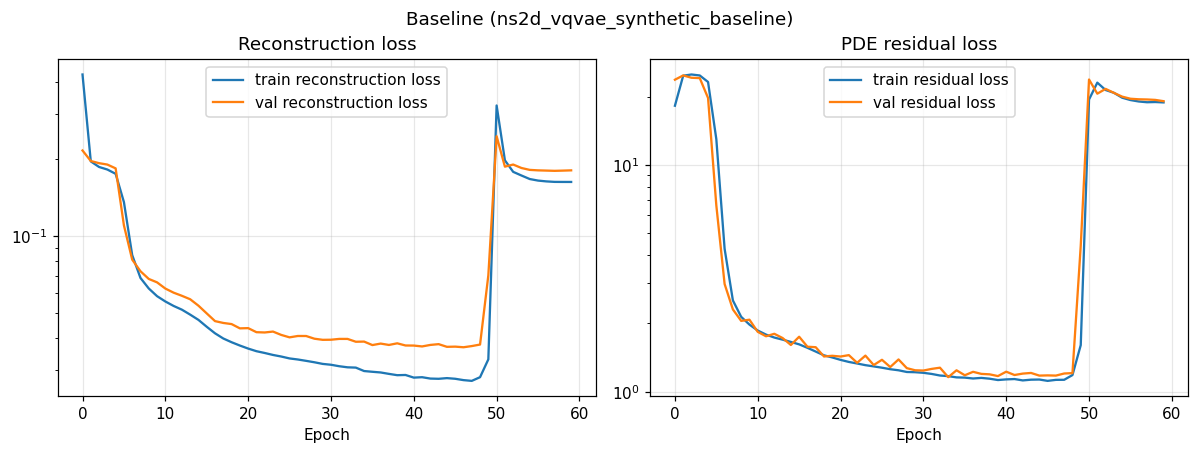

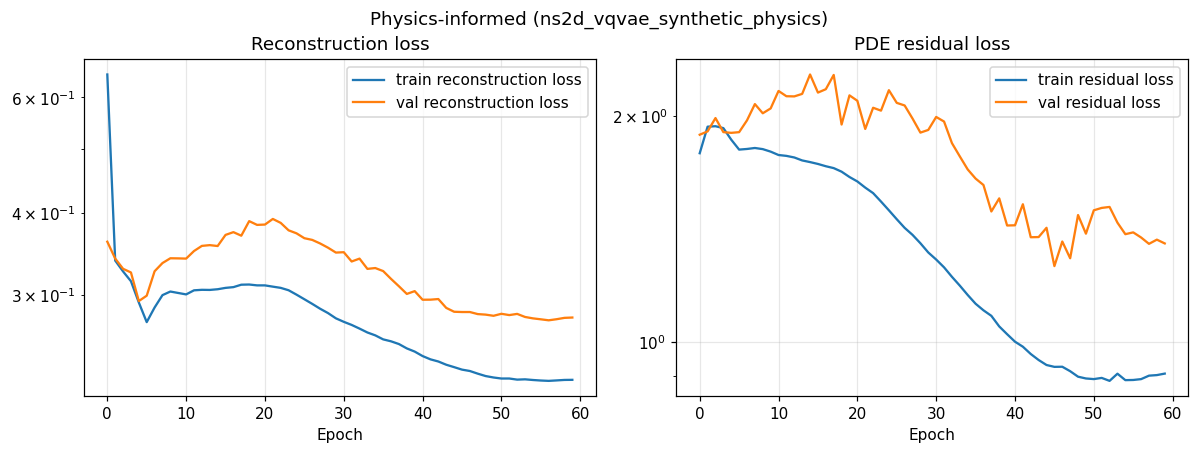

In [2]:
def load_history(run_name: str) -> dict:
    path = OUTPUT_DIR / "metrics" / f"{run_name}.csv"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found -- train Stage 1 first: python run.py --stage train_vqvae")
    df = pd.read_csv(path)
    return {
        "train_reconstruction_loss": df["train_reconstruction_loss"].tolist(),
        "val_reconstruction_loss": df["val_reconstruction_loss"].tolist(),
        "train_residual_loss": df.get("train_physics_loss", pd.Series(dtype=float)).tolist(),
        "val_residual_loss": df.get("val_physics_loss", pd.Series(dtype=float)).tolist(),
    }, df


BASELINE_RUN = f"ns2d_vqvae_{DATA_CONFIG.replace('data_', '')}_baseline"
PHYSICS_RUN = f"ns2d_vqvae_{DATA_CONFIG.replace('data_', '')}_physics"

baseline_history, baseline_df = load_history(BASELINE_RUN)
physics_history, physics_df = load_history(PHYSICS_RUN)

fig1a = plot_training_curves(baseline_history)
fig1a.suptitle(f"Baseline ({BASELINE_RUN})", y=1.02)
plt.show()

fig1b = plot_training_curves(physics_history)
fig1b.suptitle(f"Physics-informed ({PHYSICS_RUN})", y=1.02)
plt.show()

## Load trained models

Both frozen Stage-1 VQ-VAEs (baseline, physics-informed) and the Stage-2 flow matcher.
Architectures are resolved from each run's saved metadata JSON, so this is correct even if
Stage 1/2 were trained with `--override` architecture changes (e.g. a `configs/sweeps/`
sweep) rather than the plain default configs.


In [3]:
def load_vqvae(run_name: str, fallback_config: str) -> TransformerVQVAE:
    ckpt_path = OUTPUT_DIR / "checkpoints" / run_name / "best.pt"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"{ckpt_path} not found -- train Stage 1 first: python run.py --stage train_vqvae")
    arch = resolve_vqvae_arch_config(ckpt_path, fallback_config, experiment_cfg.output_dir)
    model = TransformerVQVAE(
        in_channels=arch.in_channels, resolution=arch.resolution, patch_size=arch.patch_size,
        embed_dim=arch.embed_dim, encoder_depth=arch.encoder_depth, decoder_depth=arch.decoder_depth,
        n_heads=arch.n_heads, mlp_ratio=arch.mlp_ratio, num_codes=arch.num_codes, code_dim=arch.code_dim,
        commitment_weight=arch.commitment_weight, ema_decay=arch.ema_decay,
        reset_after_n_batches=arch.reset_after_n_batches, dropout=arch.dropout,
    )
    return load_frozen_model(model, ckpt_path, device=DEVICE)


vqvae_baseline = load_vqvae(BASELINE_RUN, "vqvae_baseline")
vqvae_physics = load_vqvae(PHYSICS_RUN, "vqvae_physics")

flow_cfg = load_flow_matching_config()
flow_ckpt_path = OUTPUT_DIR / "checkpoints" / flow_cfg.run_name / "best.pt"
if not flow_ckpt_path.exists():
    raise FileNotFoundError(f"{flow_ckpt_path} not found -- train Stage 2 first: python run.py --stage train_flow")

flow_arch = resolve_flow_matching_arch_config(flow_ckpt_path, experiment_cfg.output_dir)
flow_model = LatentFlowMatcher(
    grid_shape=vqvae_physics.grid_shape, code_dim=vqvae_physics.codebook.code_dim,
    embed_dim=flow_arch.embed_dim, depth=flow_arch.depth, n_heads=flow_arch.n_heads,
    mlp_ratio=flow_arch.mlp_ratio, dropout=flow_arch.dropout,
)
flow_model = load_frozen_model(flow_model, flow_ckpt_path, device=DEVICE)

data_cfg = load_config(CONFIG_DIR / f"{DATA_CONFIG}.yaml")
loaders = build_dataloaders(
    experiment_cfg.data_root, data_cfg.source,
    batch_size=experiment_cfg.batch_size, num_workers=experiment_cfg.num_workers,
)
val_dataset = loaders["val"].dataset
print(f"Loaded {BASELINE_RUN}, {PHYSICS_RUN}, {flow_cfg.run_name}; validation set: {len(val_dataset)} windows")

Loaded ns2d_vqvae_synthetic_baseline, ns2d_vqvae_synthetic_physics, ns2d_flow_matching; validation set: 500 windows


## Figure 2 -- Ground truth vs reconstruction

Same validation sample, reconstructed by both variants, for a direct visual comparison.


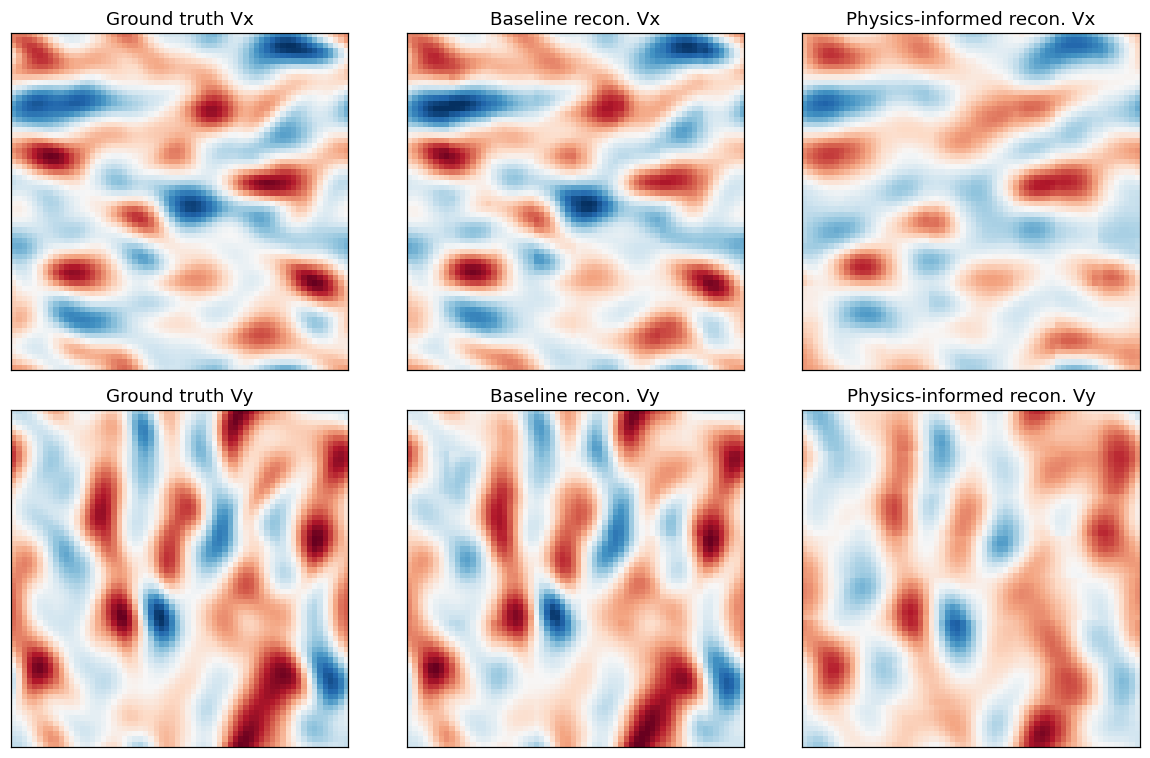

In [4]:
sample = val_dataset[0]
center = sample["center"].unsqueeze(0).to(DEVICE)
prev = sample["prev"].unsqueeze(0).to(DEVICE)
next_ = sample["next"].unsqueeze(0).to(DEVICE)

with torch.no_grad():
    recon_baseline = vqvae_baseline(center)["reconstruction"]
    recon_physics = vqvae_physics(center)["reconstruction"]

gt_phys = val_dataset.denormalize(center)[0].cpu().numpy()
recon_baseline_phys = val_dataset.denormalize(recon_baseline)[0].cpu().numpy()
recon_physics_phys = val_dataset.denormalize(recon_physics)[0].cpu().numpy()
prev_phys = val_dataset.denormalize(prev)[0].cpu().numpy()
next_phys = val_dataset.denormalize(next_)[0].cpu().numpy()

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for row, name in enumerate(("Vx", "Vy")):
    vmin, vmax = gt_phys[row].min(), gt_phys[row].max()
    axes[row, 0].imshow(gt_phys[row], cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
    axes[row, 0].set_title(f"Ground truth {name}")
    axes[row, 1].imshow(recon_baseline_phys[row], cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
    axes[row, 1].set_title(f"Baseline recon. {name}")
    axes[row, 2].imshow(recon_physics_phys[row], cmap="RdBu_r", vmin=vmin, vmax=vmax, origin="lower")
    axes[row, 2].set_title(f"Physics-informed recon. {name}")
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

## Figure 3 -- Residual maps

PDE residual (vorticity transport) for the same sample, baseline vs physics-informed --
this is the most direct visual evidence for whether the physics loss actually produces a
more physically-consistent reconstruction.


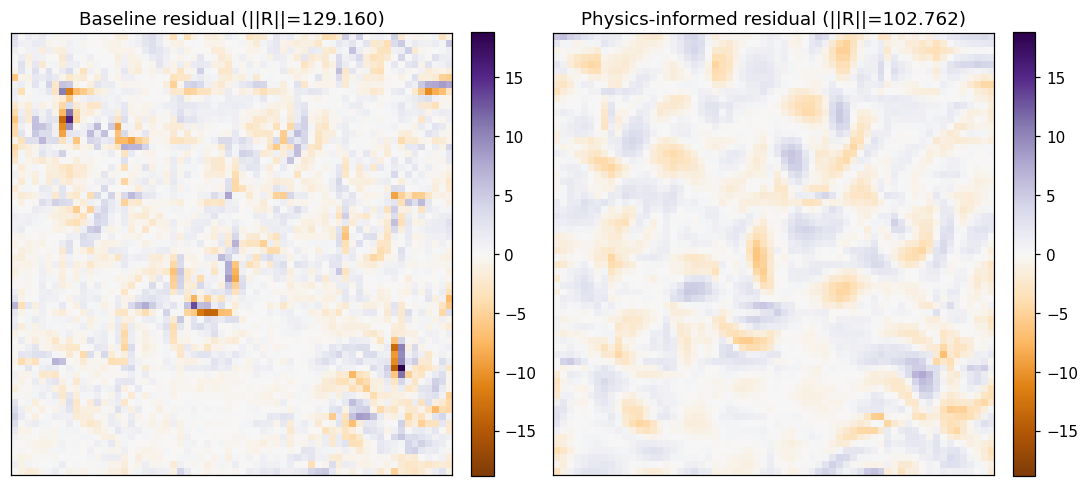

Divergence error -- baseline: 11.3134  physics-informed: 15.4611


In [5]:
def residual_and_divergence(recon_phys, backend):
    u = torch.from_numpy(recon_phys[0]).unsqueeze(0).float()
    v = torch.from_numpy(recon_phys[1]).unsqueeze(0).float()
    u_prev = torch.from_numpy(prev_phys[0]).unsqueeze(0).float()
    v_prev = torch.from_numpy(prev_phys[1]).unsqueeze(0).float()
    u_next = torch.from_numpy(next_phys[0]).unsqueeze(0).float()
    v_next = torch.from_numpy(next_phys[1]).unsqueeze(0).float()
    omega_prev = curl_2d(u_prev, v_prev, val_dataset.dx, backend)
    omega_next = curl_2d(u_next, v_next, val_dataset.dx, backend)
    residual = vorticity_transport_residual_field(
        u, v, omega_prev, omega_next, val_dataset.dt, val_dataset.dx, val_dataset.nu, backend
    )[0].numpy()
    div = divergence_error_field(u, v, val_dataset.dx, backend)[0].numpy()
    return residual, div


backend = "spectral" if val_dataset.periodic else "finite_diff"
res_baseline, div_baseline = residual_and_divergence(recon_baseline_phys, backend)
res_physics, div_physics = residual_and_divergence(recon_physics_phys, backend)

vmax = max(np.abs(res_baseline).max(), np.abs(res_physics).max())
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
im0 = axes[0].imshow(res_baseline, cmap="PuOr", vmin=-vmax, vmax=vmax, origin="lower")
axes[0].set_title(f"Baseline residual (||R||={np.linalg.norm(res_baseline):.3f})")
im1 = axes[1].imshow(res_physics, cmap="PuOr", vmin=-vmax, vmax=vmax, origin="lower")
axes[1].set_title(f"Physics-informed residual (||R||={np.linalg.norm(res_physics):.3f})")
for im, ax in zip((im0, im1), axes):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

print(f"Divergence error -- baseline: {np.linalg.norm(div_baseline):.4f}  physics-informed: {np.linalg.norm(div_physics):.4f}")

## Stage 2 -- generation evaluation

Sample from the flow matcher, decode through the frozen physics-informed VQ-VAE, and
compute every generation-quality metric (see `evaluation/evaluate_generation.py` for the
exact definitions, including the documented approximation used for PDE residual on
unconditionally-generated snapshots).


In [6]:
gen_results = evaluate_generation(
    flow_model, vqvae_physics, loaders["val"], DEVICE,
    n_samples=min(flow_cfg.eval.n_samples, len(val_dataset)),
    n_ode_steps=flow_cfg.eval.n_ode_steps, ode_method=flow_cfg.eval.ode_method,
)
{k: v for k, v in gen_results.items() if isinstance(v, (int, float))}

{'mmd': 0.18316568434238434,
 'sliced_wasserstein_distance': 0.03325782319881214,
 'spectral_energy_error': 1.6848156334357542,
 'pde_residual_norm_generated_mean': 2.7169253826141357,
 'pde_residual_norm_real_mean': 2.3652191162109375,
 'divergence_error_generated_mean': 0.4219719469547272}

## Figure 4 -- Energy spectra: ground truth vs generated

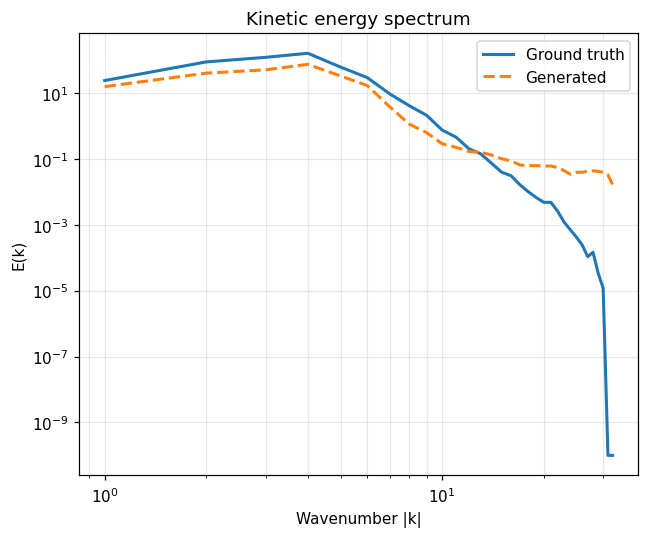

In [7]:
fig4 = plot_energy_spectra(gen_results["k_bins"], gen_results["e_gt"], gen_results["e_gen"])
plt.show()

## Figure 5 -- Vorticity fields: ground truth vs generated

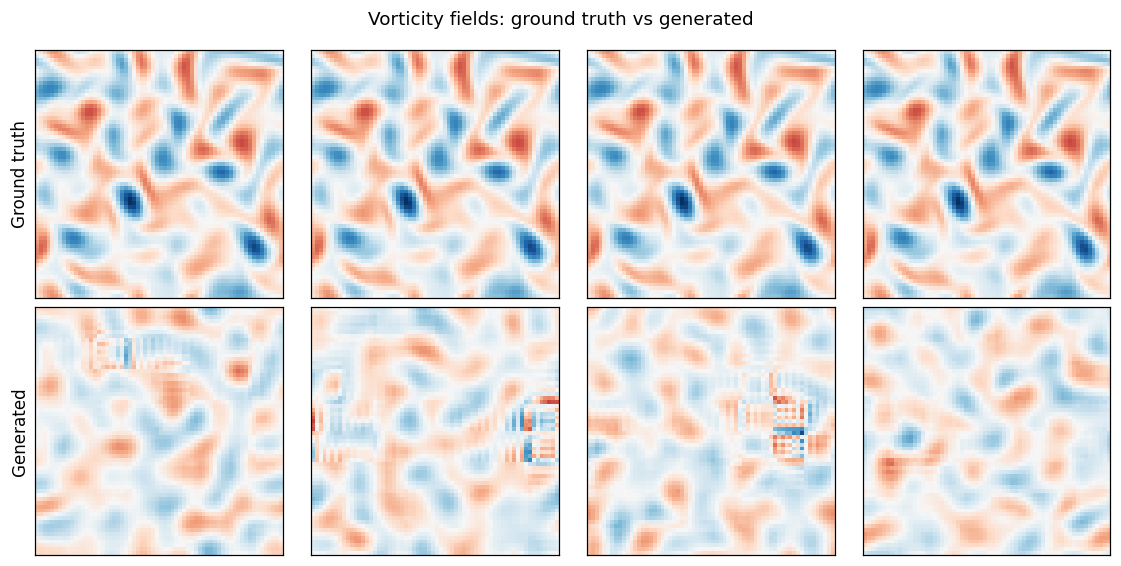

In [8]:
fig5 = plot_vorticity_comparison(gen_results["omega_gt"], gen_results["omega_gen"], n_show=4)
plt.show()

## Figure 6 -- Latent-space t-SNE: real vs generated

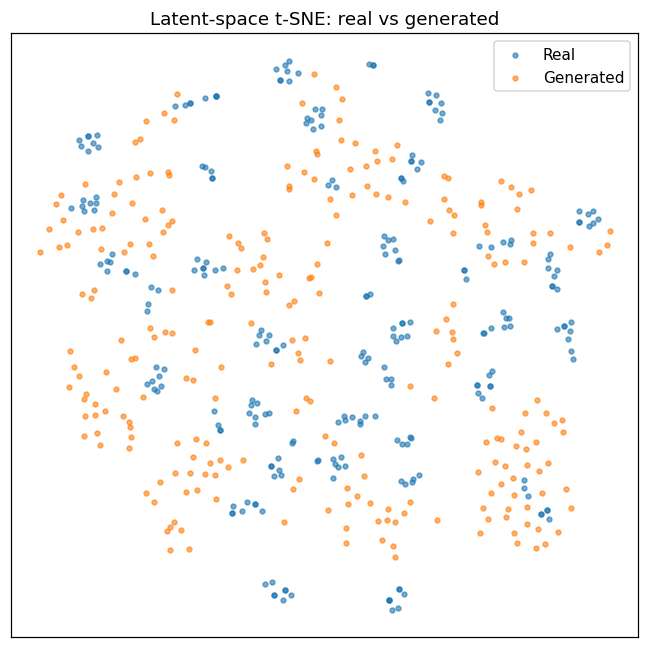

In [9]:
fig6 = compute_and_plot_tsne(gen_results["real_latents_pooled"], gen_results["gen_latents_pooled"])
plt.show()

# Drop-in UMAP alternative if `umap-learn` is installed:
# import umap
# projected = umap.UMAP(random_state=42).fit_transform(
#     np.concatenate([gen_results["real_latents_pooled"], gen_results["gen_latents_pooled"]])
# )

## Figure 7 -- Distribution comparison: MMD, Wasserstein, residual distributions

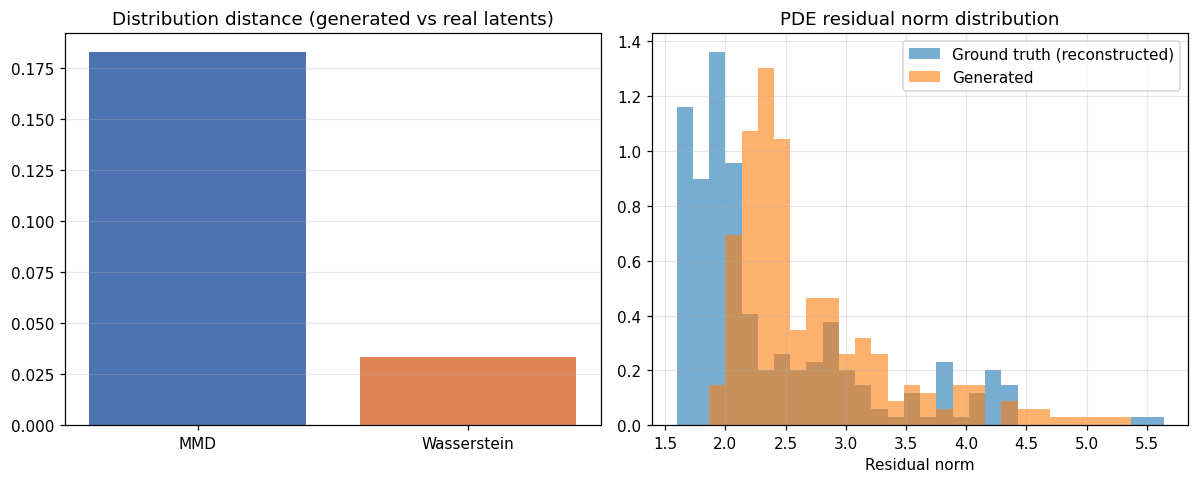

In [10]:
fig7 = plot_distribution_comparison(
    gen_results["residual_gt"], gen_results["residual_gen"],
    gen_results["mmd"], gen_results["sliced_wasserstein_distance"],
)
plt.show()

## Summary -- does physics-informed latent representation learning help?

Reconstruction quality (Stage 1) and generation quality (Stage 2), baseline vs
physics-informed, side by side.


In [11]:
summary = pd.DataFrame({
    "baseline": {
        "val_reconstruction_loss (final epoch)": baseline_df["val_reconstruction_loss"].iloc[-1],
        "val_divergence_error (final epoch)": baseline_df["divergence_error"].iloc[-1],
        "val_residual_norm (final epoch)": baseline_df["residual_norm"].iloc[-1],
        "codebook_perplexity (final epoch)": baseline_df["codebook_perplexity"].iloc[-1],
    },
    "physics-informed": {
        "val_reconstruction_loss (final epoch)": physics_df["val_reconstruction_loss"].iloc[-1],
        "val_divergence_error (final epoch)": physics_df["divergence_error"].iloc[-1],
        "val_residual_norm (final epoch)": physics_df["residual_norm"].iloc[-1],
        "codebook_perplexity (final epoch)": physics_df["codebook_perplexity"].iloc[-1],
    },
})
summary

,baseline,physics-informed
val_reconstruction_loss (final epoch),0.180442,0.277294
val_divergence_error (final epoch),1.198723,0.332219
val_residual_norm (final epoch),8.683459,2.239423
codebook_perplexity (final epoch),467.270112,474.861425


Read `val_reconstruction_loss` alongside `val_divergence_error`/`val_residual_norm`
together, not in isolation: the question this project asks is whether the
physics-informed variant achieves comparable-or-better reconstruction *while* being more
physically consistent -- a physics-informed run that only wins on the physics metrics by
sacrificing reconstruction quality is a different (and weaker) result than one that wins on
both, and the generation-quality metrics above (MMD, Wasserstein, spectral energy error,
generated-sample PDE residual) are what determine whether any Stage-1 advantage actually
carries through to the generative surrogate, which is the question in the title.
